In [1]:
##SUPERNOVA RESEARCH - Jessica Allen


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams.update({'font.size': 12})

In [5]:
df1 = pd.read_csv("sn2017erp_lco_170630.txt", sep=' ', header=None)
df2 = pd.read_csv("SN2017erp_opt_20170629_1.dat", sep='\t', header=None)
arr = []
for x in df2.values.ravel():
    y = x.split(' ')
    z = [abs(float(i)) for i in y if i!='']
    arr.append(z)
df2 = pd.DataFrame(arr, columns = [0, 1, 2, 3])

In [6]:
df1.head()

,0,1
0,3199.780273,3.011155e-15
1,3201.517558,3.019830e-15
2,3203.254843,3.185207e-15
3,3204.992128,3.320047e-15
4,3206.729413,2.011799e-15


In [7]:
df2.head() 

,0,1,2,3
0,2887.146036,1.591839e-15,5.797566e-15,18960.0
1,2889.890628,7.706091e-15,3.020638e-15,2560.0
2,2892.635243,2.834457e-15,2.260084e-15,512.0
3,2895.379879,7.985589e-15,1.805726e-15,528.0
4,2898.124539,7.883027e-15,1.659062e-15,512.0


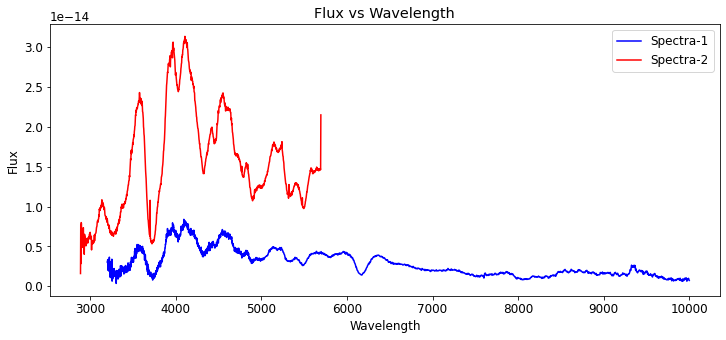

In [8]:
plt.plot(df1[0], df1[1], 'b', label='Spectra-1')
plt.plot(df2[0], df2[1], 'r', label='Spectra-2')
plt.xlabel('Wavelength')
plt.ylabel('Flux')
plt.title('Flux vs Wavelength')
plt.legend()
plt.show()

In [9]:
wavelength1 = np.arange(int(min(df1[0]))+1,max(df1[0]),10)
wavelength2 = np.arange(int(min(df2[0]))+3,max(df2[0]),10)

In [12]:
flux1 = np.interp(wavelength1, df1[0].values, df1[1].values)
flux2 = np.interp(wavelength2, df2[0].values, df2[1].values)

In [13]:
wavelength3 = np.arange(int(min(df2[0]))+3, max(df1[0]), 10)

In [14]:
flux3 = []
for i in range(len(wavelength3)):
    w3 = wavelength3[i]
    idx1, idx2 = None, None
    try:
        idx1 = wavelength1.tolist().index(w3)
    except:
        pass
    try:
        idx2 = wavelength2.tolist().index(w3)
    except:
        pass
    if idx1 is None:
        flux3.append(flux2[idx2])
        continue
    if idx2 is None:
        flux3.append(flux1[idx1])
        continue
    flux3.append(0.5*(flux1[idx1]+flux2[idx2]))
flux3 = np.array(flux3)

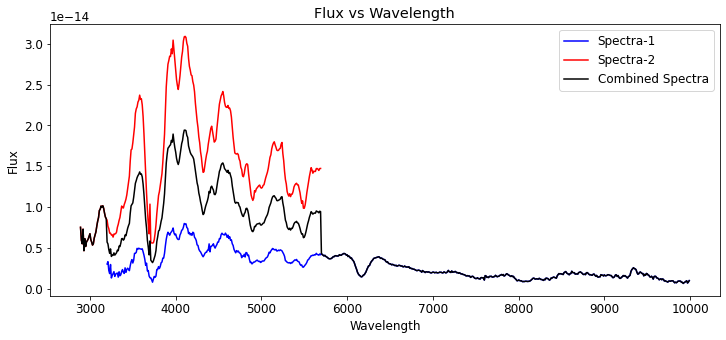

In [15]:
plt.plot(wavelength1, flux1, 'b', label='Spectra-1')
plt.plot(wavelength2, flux2, 'r', label='Spectra-2')
plt.plot(wavelength3, flux3, 'k', label='Combined Spectra')
plt.xlabel('Wavelength')
plt.ylabel('Flux')
plt.title('Flux vs Wavelength')
plt.legend()
plt.show()

In [ ]:
data = np.column_stack([wavelength3, flux3])
datafile_path = "combined_spectra.txt"
np.savetxt(datafile_path , data)